In [404]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

In [405]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

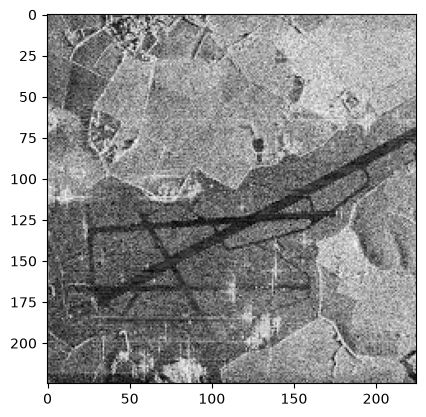

In [406]:
plt.imshow(image_gray, cmap="gray")

In [407]:
# 1

In [408]:
blurred = cv2.GaussianBlur(image_gray, (9, 9), 0);

In [409]:
canny = cv2.Canny(blurred,50,150,apertureSize = 3)

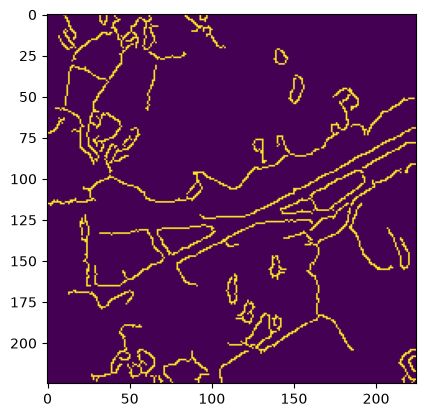

In [410]:
plt.imshow(canny)

In [411]:
lines = cv2.HoughLinesP(canny, 1, np.pi/180,threshold=80, minLineLength=100, maxLineGap=20)

In [412]:
longest = None
longest_len = 0
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line
        length = np.hypot(x2 - x1, y2 - y1)
        if length > longest_len:
            longest_len = length
            longest = (x1, y1, x2, y2)

if longest is not None:
    cv2.line(image, (longest[0], longest[1]), (longest[2], longest[3]), (0, 0, 255), 2)

In [413]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

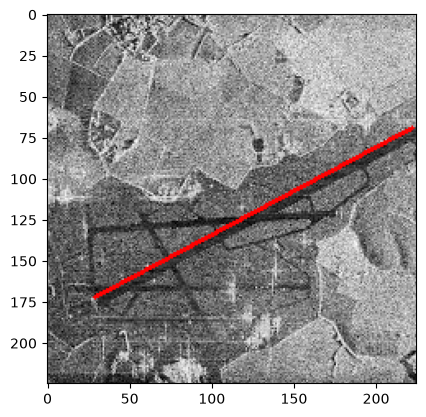

In [414]:
plt.imshow(image_rgb)

In [415]:
#2

In [416]:
# Precise binarization

In [417]:
th1 = copy.deepcopy(image_gray)

In [418]:
T = 70

th1[image_gray < T] = 0
th1[image_gray >= T] = 255

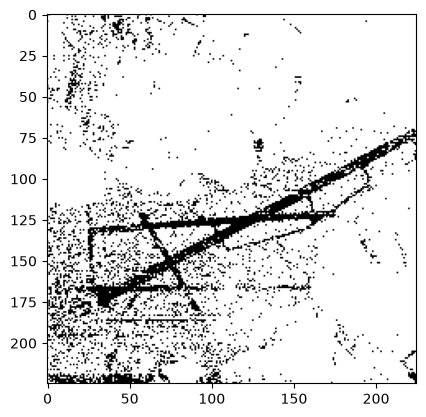

In [419]:
plt.imshow(th1, cmap="gray")

In [420]:
# Binarization Otsu

In [421]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

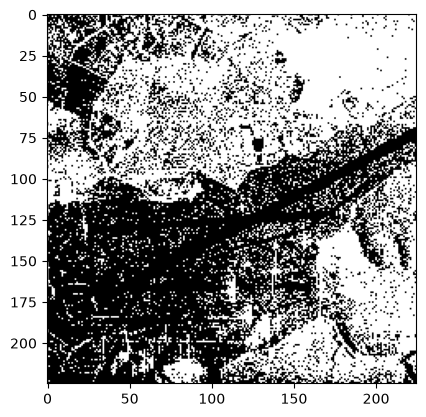

In [422]:
plt.imshow(th2, cmap="gray")

In [423]:
# Adaptive binarization

In [424]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)

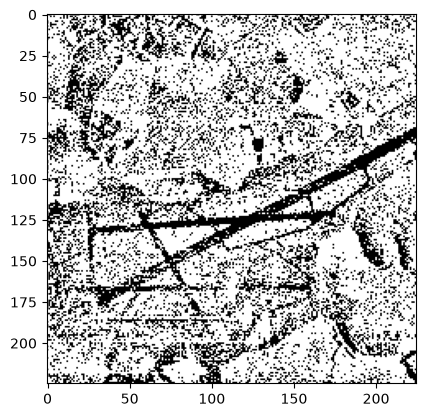

In [425]:
plt.imshow(th3, cmap="gray")